In [ ]:
import kagglehub
import os 
import pandas as pd

path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

file_path = os.path.join(path, "btcusd_1-min_data.csv")

df = pd.read_csv(file_path)

df = pd.read_csv("../data/processed/bitcoin_processed.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7476160 entries, 0 to 7476159
Data columns (total 7 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  object 
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
 6   return     float64
dtypes: float64(6), object(1)
memory usage: 399.3+ MB


# time series arima & garch

ARIMA → przewidywanie return
GARCH → przewidywanie volatility

* ARIMA

za duzo szczegolow dla garch i arima, dzielimy je na co 4 h

In [120]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp")
df = df.last("365D")

close_60m = df["Close"].resample("240min").last().dropna()
returns_series = close_60m.pct_change().dropna()

adf - stationary test

In [121]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(returns_series)

print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -22.300015707638174
p-value: 0.0


<Figure size 1000x400 with 0 Axes>

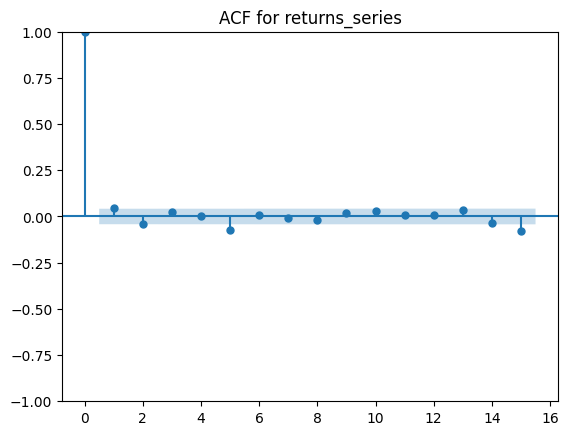

In [122]:
import matplotlib.pyplot as plt 
from statsmodels.graphics.tsaplots import plot_acf


plt.figure(figsize=(10, 4))
plot_acf(returns_series, lags=15)
plt.title("ACF for returns_series")
plt.show()




parameter q = 0 

<Figure size 1000x400 with 0 Axes>

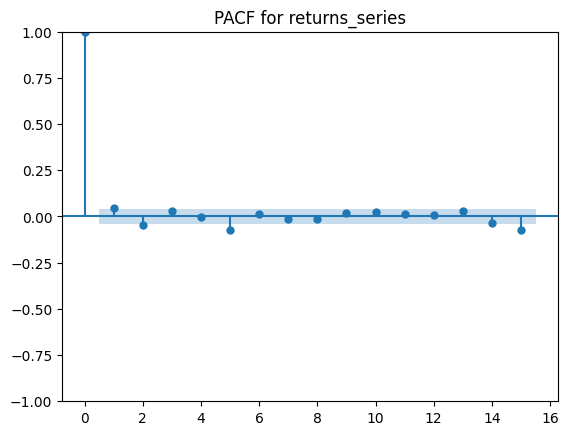

In [123]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10, 4))
plot_pacf(returns_series, lags=15, method="ywm")
plt.title("PACF for returns_series")
plt.show()

parameter p = 1

In [124]:
from statsmodels.tsa.arima.model import ARIMA

orders = [(0,0,0), (0,0,1), (1,0,1), (0,1,0)]

for order in orders:
    model = ARIMA(returns_series, order=order)
    result = model.fit()
    print(f"ARIMA{order} -> AIC: {result.aic:.4f}")

ARIMA(0, 0, 0) -> AIC: -14412.8590
ARIMA(0, 0, 1) -> AIC: -14416.1157
ARIMA(1, 0, 1) -> AIC: -14408.2470
ARIMA(0, 1, 0) -> AIC: -12994.9024


In [125]:
split = int(len(returns_series) * 0.8)

train = returns_series[:split]
test = returns_series[split:]

model = ARIMA(train, order=(0,0,1))
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

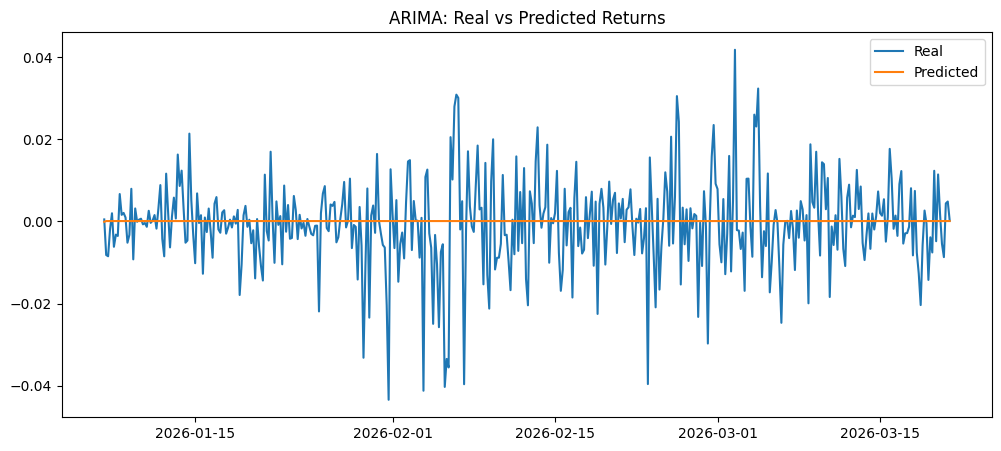

In [126]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Real")
plt.plot(test.index, pred, label="Predicted")

plt.title("ARIMA: Real vs Predicted Returns")
plt.legend()
plt.show()

testing arima on prices not returns

In [127]:
close_60m = df["Close"].resample("60min").last().dropna()

split = int(len(close_60m) * 0.8)

train = close_60m[:split]
test = close_60m[split:]

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

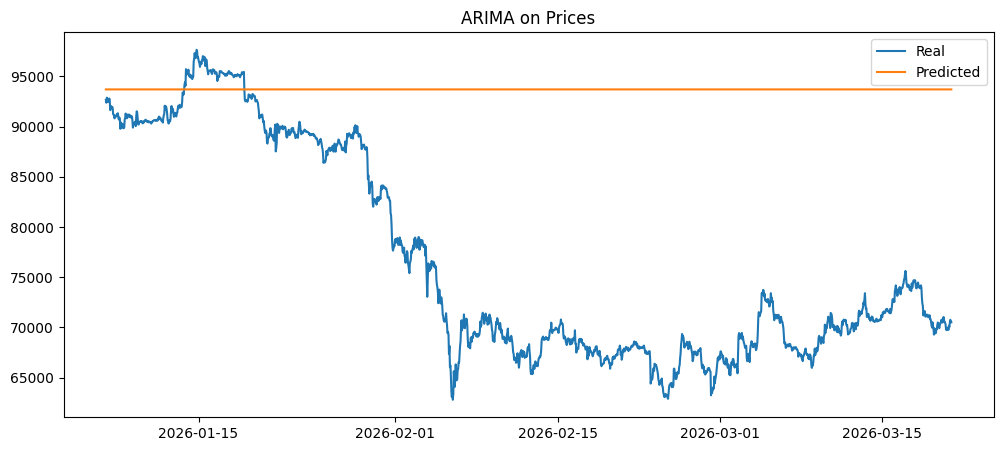

In [128]:
plt.figure(figsize=(12,5))
plt.plot(test.index, test, label="Real")
plt.plot(test.index, pred, label="Predicted")
plt.legend()
plt.title("ARIMA on Prices")
plt.show()

bad

# ARIMA for volatility


In [129]:

vol = returns_series.rolling(24).std().dropna()


<Figure size 1000x400 with 0 Axes>

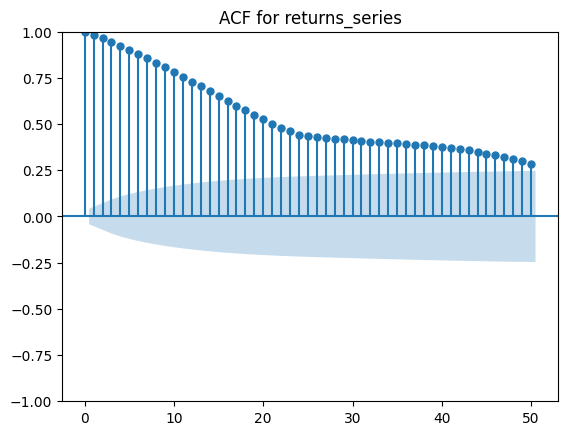

In [130]:
plt.figure(figsize=(10, 4))
plot_acf(vol, lags=50)
plt.title("ACF for returns_series")
plt.show()



<Figure size 1000x400 with 0 Axes>

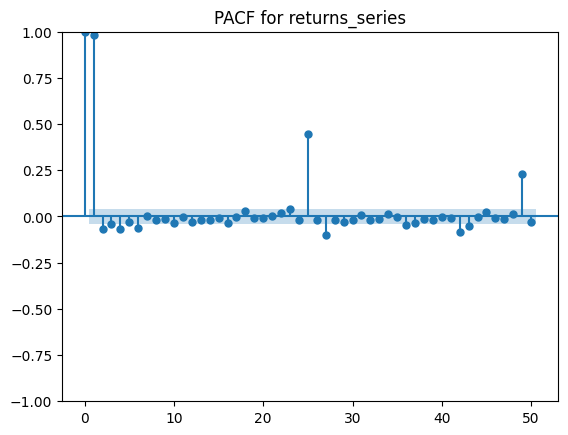

In [131]:
plt.figure(figsize=(10, 4))
plot_pacf(vol, lags=50)
plt.title("PACF for returns_series")
plt.show()


In [132]:
orders = [
    (0, 0, 0),
    (0, 1, 0),
    (0, 0, 1),
    (1,0,0),
    (2,0,0),
    (1,0,2),
    (2,0,1),
    (2,0,2),
    (3,0,1),
    (1,1,1),
    (2,1,1)
]

for order in orders:
    model = ARIMA(vol, order=order)
    result = model.fit()
    print(f"ARIMA{order} -> AIC: {result.aic:.4f}")

ARIMA(0, 0, 0) -> AIC: -18527.4824
ARIMA(0, 1, 0) -> AIC: -25960.4977
ARIMA(0, 0, 1) -> AIC: -21081.9356
ARIMA(1, 0, 0) -> AIC: -25983.2373
ARIMA(2, 0, 0) -> AIC: -25990.7022
ARIMA(1, 0, 2) -> AIC: -25991.2176
ARIMA(2, 0, 1) -> AIC: -26006.0434
ARIMA(2, 0, 2) -> AIC: -26007.9450
ARIMA(3, 0, 1) -> AIC: -25986.0879
ARIMA(1, 1, 1) -> AIC: -25962.2734
ARIMA(2, 1, 1) -> AIC: -25954.4637


In [133]:

split = int(len(vol) * 0.8)

train = vol[:split]
test = vol[split:]

model = ARIMA(train, order=(2,0,1))
model_fit = model.fit()

pred = model_fit.forecast(steps=len(test))

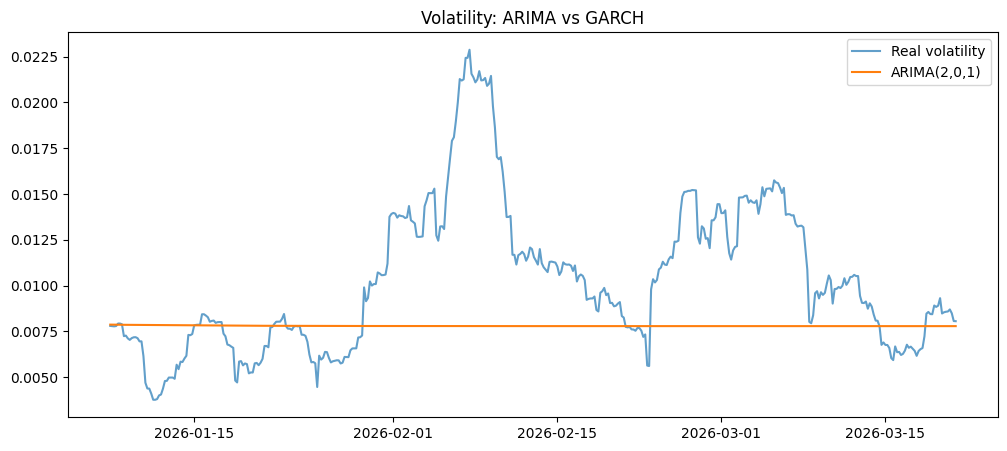

In [134]:
plt.figure(figsize=(12,5))

plt.plot(test.index, test, label="Real volatility", alpha=0.7)
plt.plot(test.index, pred, label="ARIMA(2,0,1)")

plt.legend()
plt.title("Volatility: ARIMA vs GARCH")
plt.show()

## GARCH

In [135]:
returns_series = returns_series * 100

In [136]:
from arch import arch_model

import warnings
warnings.filterwarnings("ignore")

results = []

for p in [1, 2, 3]:
    for q in [1, 2, 3]:
        try:
            model = arch_model(returns_series, vol='Garch', p=p, q=q)
            res = model.fit(disp="off")
            results.append((p, q, res.aic))
            print(f"GARCH({p},{q}) -> AIC: {res.aic:.4f}")
        except:
            pass

GARCH(1,1) -> AIC: 5514.0622
GARCH(1,2) -> AIC: 5512.0007
GARCH(1,3) -> AIC: 5514.0007
GARCH(2,1) -> AIC: 5516.0622
GARCH(2,2) -> AIC: 5508.5228
GARCH(2,3) -> AIC: 5510.5228
GARCH(3,1) -> AIC: 5518.0622
GARCH(3,2) -> AIC: 5507.0010
GARCH(3,3) -> AIC: 5509.0010


In [137]:
model = arch_model(returns_series, vol='Garch', p=1, q=1)
garch_fit = model.fit()

print(garch_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 12425.526965973666
Iteration:      2,   Func. Count:     15,   Neg. LLF: 963727547210.5034
Iteration:      3,   Func. Count:     24,   Neg. LLF: 3391.689448341591
Iteration:      4,   Func. Count:     32,   Neg. LLF: 3024.512256055307
Iteration:      5,   Func. Count:     40,   Neg. LLF: 2758.249537408575
Iteration:      6,   Func. Count:     46,   Neg. LLF: 2753.222825078532
Iteration:      7,   Func. Count:     52,   Neg. LLF: 2753.032952959861
Iteration:      8,   Func. Count:     57,   Neg. LLF: 2753.031212435394
Iteration:      9,   Func. Count:     62,   Neg. LLF: 2753.0311115517898
Iteration:     10,   Func. Count:     67,   Neg. LLF: 2753.031110476711
Iteration:     11,   Func. Count:     71,   Neg. LLF: 2753.0311104762604
Optimization terminated successfully    (Exit mode 0)
            Current function value: 2753.031110476711
            Iterations: 11
            Function evaluations: 71
            Gradient evaluations:

In [138]:
split = int(len(returns_series) * 0.8)

train = returns_series.iloc[:split] 
test = returns_series.iloc[split:] 


model = arch_model(train, vol="Garch", p=1, q=1)
garch_fit = model.fit(disp="off")

forecast = garch_fit.forecast(horizon=1, reindex=False)

print(forecast.variance.tail())

                 h.1
Timestamp           
2026-01-07  1.124756


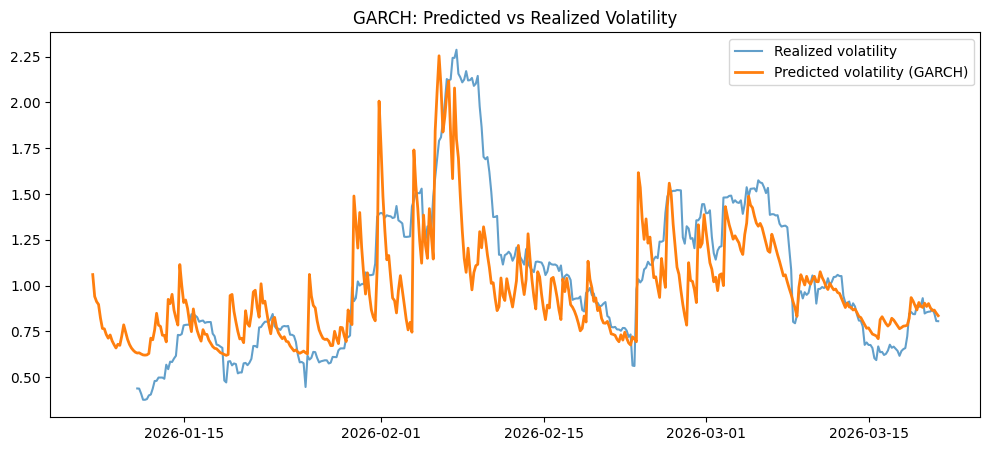

In [139]:
from arch import arch_model
import pandas as pd
import matplotlib.pyplot as plt

split = int(len(returns_series) * 0.8)

train = returns_series.iloc[:split]
test = returns_series.iloc[split:]

pred_vol = []

for i in range(len(test)):
    data_up_to_now = pd.concat([train, test.iloc[:i]])
    model = arch_model(data_up_to_now, vol="Garch", p=1, q=1)
    fit = model.fit(disp="off")
    forecast = fit.forecast(horizon=1, reindex=False)
    
    # prognozowana wariancja na 1 krok naprzód
    var_pred = forecast.variance.values[-1, 0]
    pred_vol.append(var_pred ** 0.5)

pred_vol = pd.Series(pred_vol, index=test.index)

# realized volatility na teście
realized_vol = test.rolling(24).std()

plt.figure(figsize=(12, 5))
plt.plot(realized_vol.index, realized_vol, label="Realized volatility", alpha=0.7)
plt.plot(pred_vol.index, pred_vol, label="Predicted volatility (GARCH)", linewidth=2)

plt.title("GARCH: Predicted vs Realized Volatility")
plt.legend()
plt.show()

TO DO:
* dla garch i arimy robiny log returny (bez standaryzacji) -> predykcja volatility 
* dla ML log returny (nie volatiliuty) -> predykcja return lub predykcja